In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

# $Defining$ $the$ $Function$

In [2]:
def f(x):
    return x**3 - (1/2)
    
def f_def(x): 
    return 3*x**2


# $Newton$ $Raphson$ $Method$



In [17]:
def newton_raphson_iteration(x0, tolerance, max_iteration = 100 ):
    
    itera = []
    x_values = []
    fx_values = []
    error = [] 
    err = 0
    m = 1 #multiple root case 
    i = 0 
    itera.append(i)
    x_values.append(x0)
    fx_values.append(f(x0))
    error.append(err)

    while i < max_iteration:
        fx = f(x0)
        f_prime = f_def(x0)

        if f_prime == 0:
            print("Derivative is zero. Stopping iteration ")   
            break 

        x1 = x0 - (fx/f_prime)
        err = abs(x1 - x0) 
         
        i+= 1
        itera.append(i)
        x_values.append(x1)
        x0 = x1 
        fx_values.append(f(x1))
        error.append(err)

        if err < tolerance:
            break

    newton_ra = pd.DataFrame({
        "Iteration" : itera , 
        "x_n" :x_values ,
        "f(x_n)"  :fx_values,
        "error " :error
    })

    return newton_ra

initial_guess = [0, 1, 1/2]
table_nR = []
for i in initial_guess:
    value = newton_raphson_iteration(i ,1e-8, 100 )
    table_nR.append(value)

for i in range(3):
    print (f"\n For the initial guess x0 = {initial_guess[i]}")
    print(table_nR[i])


Derivative is zero. Stopping iteration 

 For the initial guess x0 = 0
   Iteration  x_n  f(x_n)  error 
0          0    0    -0.5       0

 For the initial guess x0 = 1
   Iteration       x_n        f(x_n)        error 
0          0  1.000000  5.000000e-01  0.000000e+00
1          1  0.833333  7.870370e-02  1.666667e-01
2          2  0.795556  3.513986e-03  3.777778e-02
3          3  0.793705  8.168277e-06  1.850707e-03
4          4  0.793701  4.447964e-11  4.322063e-06
5          5  0.793701 -1.110223e-16  2.353573e-11

 For the initial guess x0 = 0.5
   Iteration       x_n        f(x_n)        error 
0          0  0.500000 -3.750000e-01  0.000000e+00
1          1  1.000000  5.000000e-01  5.000000e-01
2          2  0.833333  7.870370e-02  1.666667e-01
3          3  0.795556  3.513986e-03  3.777778e-02
4          4  0.793705  8.168277e-06  1.850707e-03
5          5  0.793701  4.447964e-11  4.322063e-06
6          6  0.793701 -1.110223e-16  2.353573e-11


# $Muller$ $Method $


In [18]:
def muller_method(x0, x1, x2 ,tol, max_iteration):
    x = [x0, x1, x2]
    h = 0 
    h_pre = 0 
    lamb = 0 
    lamb_next = 0 
    error = [np.nan, np.nan, np.nan]

    k=2
    k_new = [(k-2), (k-1), k]

    while k < max_iteration:
        h = x[k] - x[k-1]
        h_pre = x[k-1] - x[k-2]

        lamb = h/h_pre
        delta = 1 + lamb

        g = ((lamb**2)*f(x[k-2])) - ((delta**2)*f(x[k-1])) + ((lamb + delta) * f(x[k]))
        c = lamb * ((lamb * f(x[k-2])) - (delta * f(x[k-1])) + f(x[k]))

        denom_1 = g + np.sqrt((g**2) - (4*delta*c*f(x[k])))
        denom_2 = g - np.sqrt((g**2) - (4*delta*c*f(x[k])))

        if abs(denom_1) > abs(denom_2) : 
            lamb_next = -1 * ((2*delta*f(x[k]))/denom_1)
        else:
            lamb_next = -1 * ((2*delta*f(x[k]))/denom_2)
        
        x_new = x[k] + ((x[k] - x[k-1]) * lamb_next)
        x.append(x_new)

        
        err = abs(x_new - x[k])
        error.append(err)
        k = k+1 
        k_new.append(k)
        if err < tol:
            break
    
    muller = pd.DataFrame({
        "iteration" : k_new,
        "x" : x,
        "error" : error
    })

    return muller

table_muller = muller_method(0 , 1 , (1/2), 1e-8, 100)
print(table_muller)


   iteration         x         error
0          0  0.000000           NaN
1          1  1.000000           NaN
2          2  0.500000           NaN
3          3  0.767592  2.675919e-01
4          4  0.792888  2.529588e-02
5          5  0.793704  8.160803e-04
6          6  0.793701  3.311696e-06
7          7  0.793701  3.718503e-11


# $6^{th}$ $order$ $Method$

In [ ]:
def six_order_method(x0, tol , max_iteration):
    '''x = [x0]
    error = [np.nan]

    i = 0
    iteration = [i]
    while i < max_iteration:
        w = x[i] - ((f(x[i]))/ (f_def(x[i])))

        z = w - ((f(w) / f_def(x[i]))*(((2*f(x[i]) - f(w)))/((2*f(x[i]))-(5*f(w)))))

        x_new = z - ((f(z)/(f_def(x[i])))*((f(x[i]) - f(w)))/(f(x[i]) - (3*f(w))))

        x.append(x_new)
        err = abs(x_new - x[i])
        error.append(err)
        i+=1
        iteration.append(i)
        if err < tol:
            break''' 
    
    x = [x0]
    error = [np.nan]
    i = 0
    iteration = [i]
    while i < max_iteration:
        fxi = f(x[i])
        fdefxi = f_def(x[i])
        if fdefxi == 0:
            print(f"Stopped: Derivative zero at x = {x[i]}")
            break
        
        w = x[i] - (fxi / fdefxi)
        fw = f(w)
        denominator_z = 2*fxi - 5 * fw
        if denominator_z == 0:
            print(f"Stopped: denominator zero at z step, iteration {i}")
            break
        
        z = w - (fw / fdefxi) * ((2 * fxi - fw) / denominator_z)
        fz = f(z)
        denominator_xnp1 = fxi - 3 * fw
        if denominator_xnp1 == 0:
            print(f"Stopped: denominator zero at x[n+1] step, iteration {i}")
            break
        
        x_new = z - (fz / fdefxi) * ((fxi - fw) / denominator_xnp1)

        x.append(x_new)
        err = abs(x_new - x[i])
        error.append(err)
        i += 1
        iteration.append(i)
        if err < tol:
            break
    
    six_or = pd.DataFrame({
        "iteration" :iteration,
        "x ": x,
        "error ": error
    })

    return six_or

initial_guess = [0, 1, 1/2]
table_six = []
for i in initial_guess:
    value = six_order_method(i ,1e-8, 100 )
    table_six.append(value)

for i in range(3):
    print (f"\n For the initial guess x0 = {initial_guess[i]}")
    print(table_six[i])


Stopped: Derivative zero at x = 0

 For the initial guess x0 = 0
   iteration  x   error 
0          0   0     NaN

 For the initial guess x0 = 1
   iteration        x         error 
0          0  1.000000           NaN
1          1  0.793702  2.062983e-01
2          2  0.793701  1.196967e-06
3          3  0.793701  1.110223e-16

 For the initial guess x0 = 0.5
   iteration        x         error 
0          0  0.500000           NaN
1          1  0.798874  2.988743e-01
2          2  0.793701  5.173734e-03
3          3  0.793701  6.439294e-15


# $ Plotting $

In [41]:
for i in range(3):
    table_nR[i] = table_nR[i].dropna()
    table_six[i] = table_six[i].dropna()
table_muller = table_muller.dropna()    

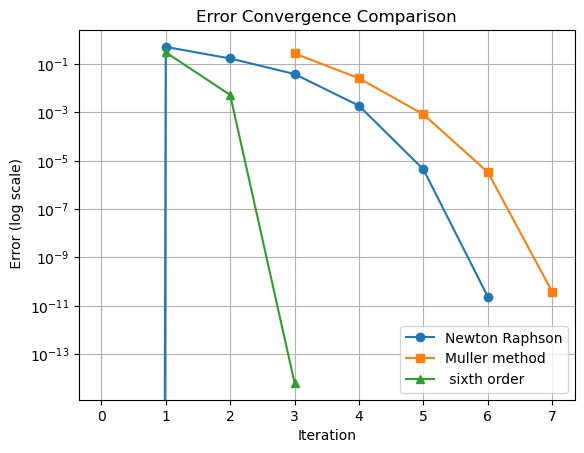

In [43]:
plt.plot(table_nR[2]["error "], label = "Newton Raphson", marker = 'o')
plt.plot(table_muller["error"], label = "Muller method", marker= 's')
plt.plot(table_six[2]["error "], label = " sixth order", marker = '^')

plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel(" Error (log scale)")
plt.title("Error Convergence Comparison")
plt.legend()
plt.grid()

plt.show ()